<a href="https://colab.research.google.com/github/rodrigopuertas3-ai/Paper_Bordetella/blob/main/Montecarlo_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Proteínas cargadas: 2758
Longitud total de residuos: 863,547
IEDB dummy HLA-I: 200 entradas | HLA-II: 150 entradas

Corriendo piloto HLA-I...
Corriendo piloto HLA-II...

--- HLA-I ---
Distribución nula: media=0.006, std=0.079, max=2
n1 (pipeline) = 8
z-score = 101.02
p empírico (P[azar >= n1]) = 0.00000

--- HLA-II ---
Distribución nula: media=0.002, std=0.049, max=1
n1 (pipeline) = 6
z-score = 122.57
p empírico (P[azar >= n1]) = 0.00000

Figura guardada en /content/drive/MyDrive/Colab_Notebooks/montecarlo_pilot_result.png


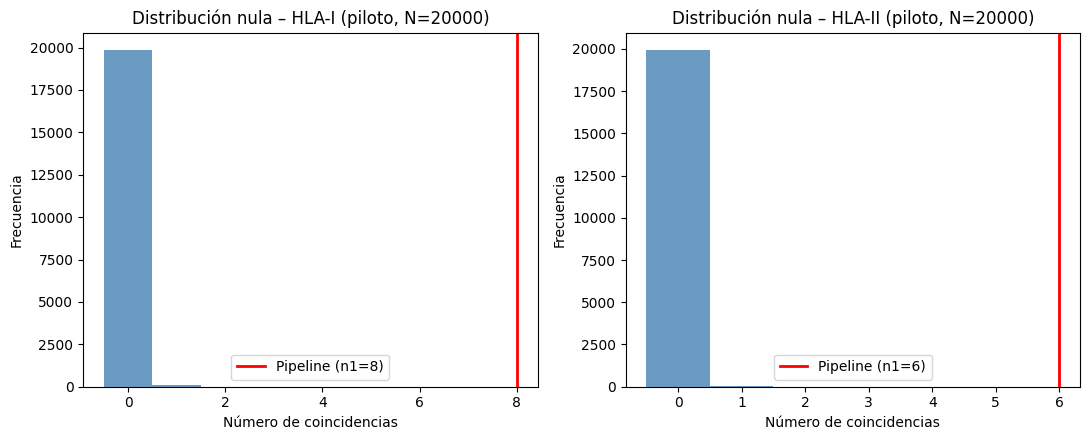

In [17]:
"""
Prueba piloto (pequeña escala) del Monte Carlo del paper de B. pertussis.
Objetivo: validar la lógica de:
  1) muestreo aleatorio de k-mers desde el proteoma
  2) comparación contra una base "IEDB" (aquí simulada/dummy)
  3) construcción de distribución nula y cálculo de significancia (z-score, p-value empírico)

Antes de escalar a 10,000,000 de iteraciones con la IEDB real, corremos con
parámetros reducidos para confirmar que todo funciona correctamente.
"""

import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

random.seed(42)
np.random.seed(42)

# ----------------------------
# 1. Cargar proteoma real
# ----------------------------
def load_proteome(fasta_path):
    seqs = []
    current = []
    with open(fasta_path) as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if current:
                    seqs.append("".join(current))
                current = []
            else:
                current.append(line)
        if current:
            seqs.append("".join(current))
    return [s for s in seqs if len(s) >= 15]  # descartamos proteínas muy cortas

PROTEOME_PATH = "/content/drive/MyDrive/Colab_Notebooks/proteoma.faa"
proteome = load_proteome(PROTEOME_PATH)
print(f"Proteínas cargadas: {len(proteome)}")
print(f"Longitud total de residuos: {sum(len(p) for p in proteome):,}")

# ----------------------------
# 2. Generar base IEDB simulada (DUMMY)
#    Se construye tomando una pequeña muestra de k-mers reales del proteoma
#    (para poder tener matches "esperables") + ruido aleatorio.
#    ESTO SE REEMPLAZARÁ por la IEDB real en la corrida final.
# ----------------------------
def random_kmer(proteome, k):
    prot = random.choice(proteome)
    if len(prot) < k:
        return random_kmer(proteome, k)
    start = random.randint(0, len(prot) - k)
    return prot[start:start + k]

def build_dummy_iedb(proteome, n_hla1=200, n_hla2=150, noise_frac=0.5):
    """Simula una base IEDB pequeña: mitad tomada del proteoma (matches posibles),
    mitad aleatoria (ruido, sin relación biológica)."""
    aa = "ACDEFGHIKLMNPQRSTVWY"
    iedb_hla1, iedb_hla2 = set(), set()

    for _ in range(int(n_hla1 * (1 - noise_frac))):
        k = random.choice([8, 9])
        iedb_hla1.add(random_kmer(proteome, k))
    for _ in range(int(n_hla1 * noise_frac)):
        k = random.choice([8, 9])
        iedb_hla1.add("".join(random.choice(aa) for _ in range(k)))

    for _ in range(int(n_hla2 * (1 - noise_frac))):
        iedb_hla2.add(random_kmer(proteome, 15))
    for _ in range(int(n_hla2 * noise_frac)):
        iedb_hla2.add("".join(random.choice(aa) for _ in range(15)))

    return iedb_hla1, iedb_hla2

iedb_hla1, iedb_hla2 = build_dummy_iedb(proteome)
print(f"IEDB dummy HLA-I: {len(iedb_hla1)} entradas | HLA-II: {len(iedb_hla2)} entradas")

# ----------------------------
# 3. Generación de sets aleatorios de epítopos + comparación
# ----------------------------
def generate_random_set(proteome, n, k_choices):
    return [random_kmer(proteome, random.choice(k_choices)) for _ in range(n)]

def count_matches(random_set, iedb_set):
    """Coincidencia = match exacto O la secuencia aleatoria está contenida
    dentro de un epítopo de la IEDB (o viceversa), replicando el criterio del paper."""
    matches = 0
    for seq in random_set:
        hit = False
        for ref in iedb_set:
            if seq == ref or seq in ref or ref in seq:
                hit = True
                break
        if hit:
            matches += 1
    return matches

# ----------------------------
# 4. PILOTO a pequeña escala
# ----------------------------
N_HLA1 = 20          # en el paper: 1246
N_HLA2 = 15           # en el paper: 835
K_HLA1 = [8, 9]
K_HLA2 = [15]
N_ITER = 20000         # en el paper: 10,000,000 (piloto reducido)

def run_montecarlo(proteome, iedb_set, n_epitopes, k_choices, n_iter):
    results = np.zeros(n_iter, dtype=int)
    for i in range(n_iter):
        rand_set = generate_random_set(proteome, n_epitopes, k_choices)
        results[i] = count_matches(rand_set, iedb_set)
    return results

print("\nCorriendo piloto HLA-I...")
dist_hla1 = run_montecarlo(proteome, iedb_hla1, N_HLA1, K_HLA1, N_ITER)
print("Corriendo piloto HLA-II...")
dist_hla2 = run_montecarlo(proteome, iedb_hla2, N_HLA2, K_HLA2, N_ITER)

# ----------------------------
# 5. "Resultado del pipeline" (n1) simulado para la prueba
#    En la corrida real, este valor sale de tus epítopos predichos reales
#    comparados contra la IEDB real.
# ----------------------------
pipeline_set_hla1 = list(iedb_hla1)[:8] + generate_random_set(proteome, N_HLA1 - 8, K_HLA1)
pipeline_set_hla2 = list(iedb_hla2)[:6] + generate_random_set(proteome, N_HLA2 - 6, K_HLA2)
n1_hla1 = count_matches(pipeline_set_hla1, iedb_hla1)
n1_hla2 = count_matches(pipeline_set_hla2, iedb_hla2)

def summarize(dist, n1, label):
    mean, std = dist.mean(), dist.std()
    z = (n1 - mean) / std if std > 0 else float("nan")
    p_empirical = (dist >= n1).sum() / len(dist)
    print(f"\n--- {label} ---")
    print(f"Distribución nula: media={mean:.3f}, std={std:.3f}, max={dist.max()}")
    print(f"n1 (pipeline) = {n1}")
    print(f"z-score = {z:.2f}")
    print(f"p empírico (P[azar >= n1]) = {p_empirical:.5f}")
    return mean, std, z, p_empirical

stats_hla1 = summarize(dist_hla1, n1_hla1, "HLA-I")
stats_hla2 = summarize(dist_hla2, n1_hla2, "HLA-II")

# ----------------------------
# 6. Graficar (equivalente a Figura 5 del paper)
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, dist, n1, label in [
    (axes[0], dist_hla1, n1_hla1, "HLA-I"),
    (axes[1], dist_hla2, n1_hla2, "HLA-II"),
]:
    bins = np.arange(0, dist.max() + 2) - 0.5
    ax.hist(dist, bins=bins, color="steelblue", alpha=0.8)
    ax.axvline(n1, color="red", linewidth=2, label=f"Pipeline (n1={n1})")
    ax.set_title(f"Distribución nula – {label} (piloto, N={N_ITER})")
    ax.set_xlabel("Número de coincidencias")
    ax.set_ylabel("Frecuencia")
    ax.legend()

plt.tight_layout()
out_path = "/content/drive/MyDrive/Colab_Notebooks/montecarlo_pilot_result.png"
plt.savefig(out_path, dpi=150)
print(f"\nFigura guardada en {out_path}")